## 06 More on queries (2/2)

### Setup

Let's import a well-structured database, with several tables and relationships, to be used as a sandbox for further exercises on queries.

The database is freely available and is taken from the IMDb (Internet Movie Database) website (https://www.imdb.com/interfaces/), although severely slimmed down.

This database contains several tables with information about movies, TV shows, people involved in the entertainment industry, and more, spanning from the 1890s to recent years.

To simplify the execution of queries, we will work with a slimmed-down version of the entire database, with still plenty of records for us to extract interesting information.

To start working with the IMDb database, we need to import it into our environment. The database `.sql` file should be downloaded from the link on Moodle and copied into the `/mysql/dbs` folder of the GitHub repository so that it will be found in the mounted volume at the location: `/mapd-workspace/dbs/IMDb_pruned.sql`.

1. Create a new DB named `IMDb`
2. Import the content of the file `/mapd-workspace/dbs/IMDb_pruned.sql` into the newly created DB
(this might take a minute or two...)

In [23]:
import matplotlib.pyplot as plt

In [1]:
%reload_ext sql
%env DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

env: DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db


In [2]:
%%sql
CREATE DATABASE IF NOT EXISTS IMDb;

1 rows affected.


[]

**In bash inside container run:**

bash-5.1#
```bash
mysql -u root -p IMDb < /mapd-workspace/dbs/IMDb_pruned_new.sql
```
---> NB old won't work because no indexes

In [3]:
#%%sql
#SHOW DATABASES;

In [5]:
%%sql
USE IMDb;

 * mysql+mysqlconnector://root:***@db
0 rows affected.


[]

#### Check which tables are available

In [6]:
%%sql
SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
7 rows affected.


Tables_in_IMDb
Directors
Episode_belongs_to
Had_role
Names_
Title_genres
Title_ratings
Titles


### Describe the content of table `Names_`

In [3]:
%%sql
DESCRIBE Names_;

 * mysql+mysqlconnector://root:***@db
(mysql.connector.errors.ProgrammingError) 1046 (3D000): No database selected
[SQL: DESCRIBE Names_;]
(Background on this error at: https://sqlalche.me/e/20/f405)


In [14]:
#---> of actors, directors etc

In [18]:
%%sql
SELECT COUNT(*) as "Number of entries" FROM Names_;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


Number of entries
156311


### Study the distribution of the year of birth of all people included in the database

1. Start by limiting the query to 1000 entries
    1. Draw a histogram of the year of birth
    1. Draw a second histogram with the year of birth of the 1000 youngest people in the list

In [25]:
import matplotlib.pyplot as plt

#### 1.A

In [23]:
%%sql
SELECT DISTINCT birth_year, COUNT(*) as counts
FROM Names_
GROUP BY birth_year
ORDER BY birth_year;

 * mysql+mysqlconnector://root:***@db
142 rows affected.


birth_year,counts
13,1
1088,1
1870,1
1873,1
1876,1
1878,1
1879,2
1886,1
1887,1
1889,1


 * mysql+mysqlconnector://root:***@db
142 rows affected.
+------------+--------+
| birth_year | counts |
+------------+--------+
|     13     |   1    |
|    1088    |   1    |
|    1870    |   1    |
|    1873    |   1    |
|    1876    |   1    |
|    1878    |   1    |
|    1879    |   2    |
|    1886    |   1    |
|    1887    |   1    |
|    1889    |   1    |
|    1890    |   3    |
|    1891    |   3    |
|    1892    |   3    |
|    1893    |   3    |
|    1894    |   4    |
|    1895    |   4    |
|    1896    |   12   |
|    1897    |   6    |
|    1898    |   17   |
|    1899    |   18   |
|    1900    |   24   |
|    1901    |   26   |
|    1902    |   33   |
|    1903    |   35   |
|    1904    |   45   |
|    1905    |   52   |
|    1906    |   64   |
|    1907    |   83   |
|    1908    |  107   |
|    1909    |  101   |
|    1910    |  112   |
|    1911    |  123   |
|    1912    |  179   |
|    1913    |  135   |
|    1914    |  199   |
|    1915    |  192   |
|    19

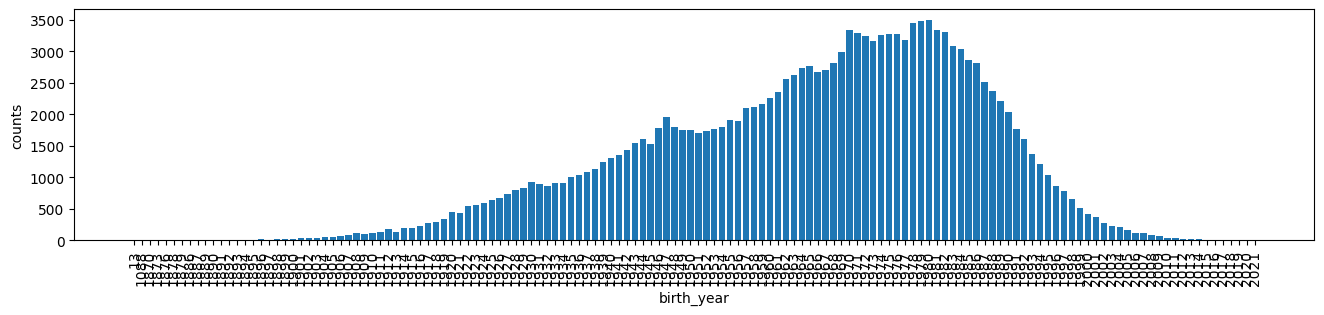

In [26]:
res_ = %sql SELECT DISTINCT birth_year, COUNT(*) as counts FROM Names_ GROUP BY birth_year ORDER BY birth_year;

print(res_)

plt.figure(figsize=(16,3))
res_.bar();
plt.xticks(rotation='vertical');

In [ ]:
#---> prettier graph?

In [40]:
%%sql
SELECT birth_year, COUNT(1) AS counts
FROM(SELECT birth_year
     FROM Names_
     ORDER BY birth_year DESC
     LIMIT 1000) AS youngest
GROUP BY birth_year
ORDER BY birth_year;

 * mysql+mysqlconnector://root:***@db
19 rows affected.


birth_year,counts
2003,126
2004,215
2005,162
2006,120
2007,107
2008,80
2009,58
2010,38
2011,32
2012,23


In [ ]:
#---> NB this nested query; aliases are mandatory for all derived tables

 * mysql+mysqlconnector://root:***@db
19 rows affected.
+------------+--------+
| birth_year | counts |
+------------+--------+
|    2003    |  126   |
|    2004    |  215   |
|    2005    |  162   |
|    2006    |  120   |
|    2007    |  107   |
|    2008    |   80   |
|    2009    |   58   |
|    2010    |   38   |
|    2011    |   32   |
|    2012    |   23   |
|    2013    |   11   |
|    2014    |   11   |
|    2015    |   5    |
|    2016    |   1    |
|    2017    |   2    |
|    2018    |   5    |
|    2019    |   1    |
|    2020    |   2    |
|    2021    |   1    |
+------------+--------+


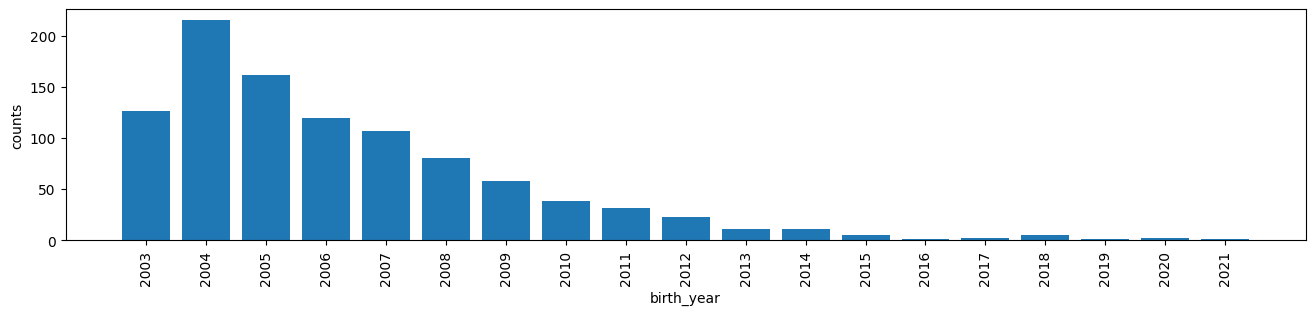

In [41]:
res_ = %sql SELECT birth_year, COUNT(1) AS counts FROM(SELECT birth_year FROM Names_ ORDER BY birth_year DESC LIMIT 1000) AS youngest GROUP BY birth_year ORDER BY birth_year;

print(res_)

plt.figure(figsize=(16,3))
res_.bar();
plt.xticks(rotation='vertical');

#### 1.B

2. Extend the query to all records in the table
    1. Check for outliers (inspect min and max)
    2. If any outlier is found, limit the query to a reasonable range (say... at least people born after 1850)
    3. Draw a new histogram with the year of birth
    4. Compute the mean and standard deviation of the year of birth

#### 2.A

In [42]:
%%sql
SELECT MAX(birth_year), MIN(birth_year)
FROM Names_;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


MAX(birth_year),MIN(birth_year)
2021,13


In [46]:
%%sql
SELECT *
FROM Names_
WHERE (birth_year<1850)
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
2 rows affected.


name_id,name_,birth_year,death_year
nm1620433,Karen Abercrombie,13,None
nm8066610,Sophie Oliver,1088,None


In [ ]:
#---> correct dates from google search o the IMDb database itself: 1976, 1988, so:

#### 2.B

In [7]:
%%sql

UPDATE Names_
SET birth_year = 1976
WHERE (name_id="nm1620433");

 * mysql+mysqlconnector://root:***@db
1 rows affected.


[]

In [8]:
%%sql

UPDATE Names_
SET birth_year = 1988
WHERE (name_id="nm8066610");

 * mysql+mysqlconnector://root:***@db
1 rows affected.


[]

In [9]:
%%sql
SELECT *
FROM Names_
WHERE ((name_id="nm1620433") OR (name_id="nm8066610"));

 * mysql+mysqlconnector://root:***@db
2 rows affected.


name_id,name_,birth_year,death_year
nm1620433,Karen Abercrombie,1976,None
nm8066610,Sophie Oliver,1988,None


#### 2.C

In [ ]:
USE IMDb;

In [18]:
%%sql
SELECT birth_year, COUNT(1) AS counts
FROM Names_
GROUP BY birth_year
ORDER BY birth_year
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


birth_year,counts
1870,1
1873,1
1876,1
1878,1
1879,2
1886,1
1887,1
1889,1
1890,3
1891,3


 * mysql+mysqlconnector://root:***@db
140 rows affected.


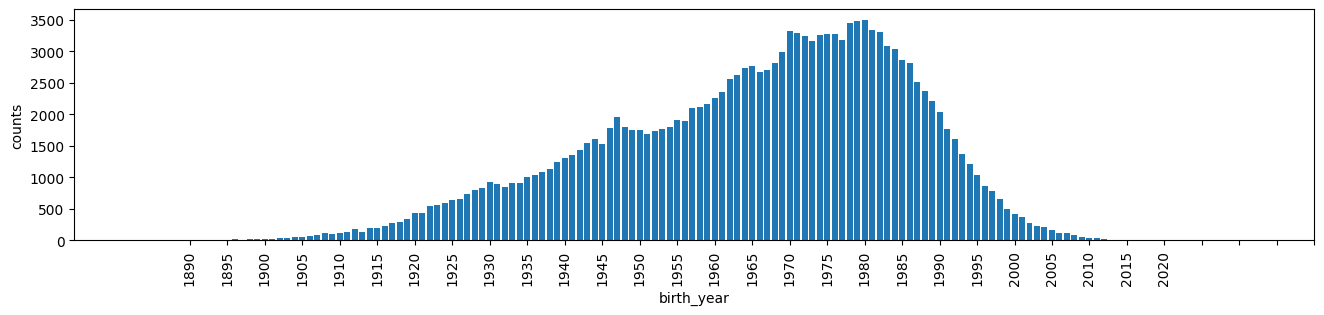

In [31]:
res_ = %sql SELECT birth_year, COUNT(1) AS counts FROM Names_ GROUP BY birth_year ORDER BY birth_year;

plt.figure(figsize=(16,3))
res_.bar();
plt.xticks(ticks=list(range(8, 160, 5)), rotation='vertical');

In [22]:
#ticks=[decade for decade in range(1870, 2031, 10)]
#print(ticks)

# ---> TODO: handle this automatically in a more general way? prettier graph?

[1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030]


#### 2.D

In [37]:
%%sql
SELECT AVG(birth_year) as mean, STD(birth_year) as STD
FROM Names_;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


mean,STD
1965.4516,19.99202438672811


### Movie stats

#### 1 - Plot the number of titles available in the database for each year over the past 25 years.

In [39]:
%%sql

SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
7 rows affected.


Tables_in_IMDb
Directors
Episode_belongs_to
Had_role
Names_
Title_genres
Title_ratings
Titles


In [41]:
%%sql
DESCRIBE Titles;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


Field,Type,Null,Key,Default,Extra
title_id,varchar(255),NO,,None,
title_type,varchar(50),YES,,None,
primary_title,text,YES,,None,
start_year,int,YES,,None,
runtime_minutes,int,YES,,None,


In [7]:
%%sql
SELECT start_year, COUNT(1) as counts
FROM Titles
WHERE (start_year>=2000)
GROUP BY start_year
ORDER BY start_year;

 * mysql+mysqlconnector://root:***@db
28 rows affected.


start_year,counts
2000,15677
2001,16598
2002,16937
2003,18189
2004,19711
2005,22746
2006,24898
2007,27860
2008,30564
2009,34450


 * mysql+mysqlconnector://root:***@db
28 rows affected.


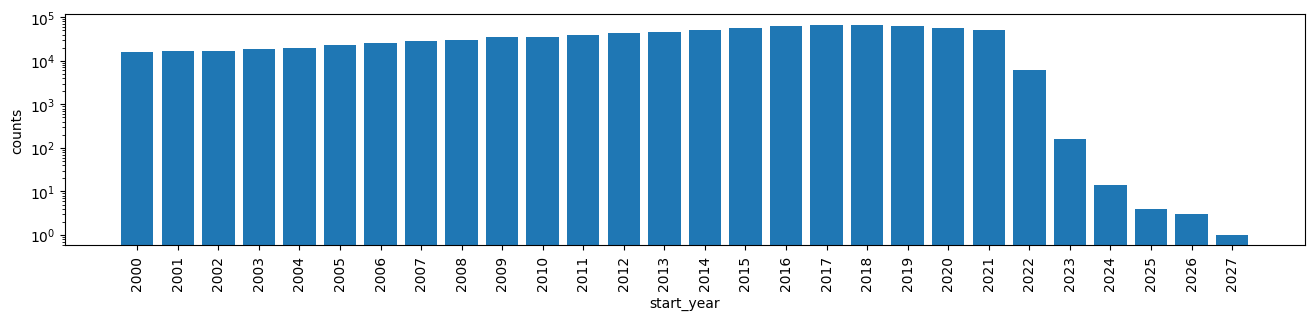

In [47]:
res_ = %sql SELECT start_year, COUNT(1) as counts    FROM Titles    WHERE (start_year>=2000)    GROUP BY start_year    ORDER BY start_year;

plt.figure(figsize=(16,3))
res_.bar();
plt.xticks(rotation='vertical');
plt.yscale('log')

In [ ]:
#---> TODO: include in each year TV series running in that year (but started before)?

#### 2 - List the names of all actors who have portrayed the character Spider-Man in movies, along with the corresponding movie titles.

In [7]:
%%sql

DESCRIBE Had_role;

 * mysql+mysqlconnector://root:***@db
3 rows affected.


Field,Type,Null,Key,Default,Extra
title_id,varchar(255),NO,PRI,None,
name_id,varchar(255),NO,PRI,None,
role_,varchar(255),NO,PRI,None,


In [8]:
%%sql
DESCRIBE Names_;

 * mysql+mysqlconnector://root:***@db
4 rows affected.


Field,Type,Null,Key,Default,Extra
name_id,varchar(255),NO,PRI,None,
name_,varchar(255),NO,,None,
birth_year,smallint,YES,,None,
death_year,smallint,YES,,None,


In [9]:
%%sql
DESCRIBE Titles;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


Field,Type,Null,Key,Default,Extra
title_id,varchar(255),NO,PRI,None,
title_type,varchar(50),YES,,None,
primary_title,text,YES,,None,
start_year,int,YES,,None,
runtime_minutes,int,YES,,None,


In [14]:
%%sql

SELECT N.name_, T.primary_title, HR.role_, T.start_year
FROM Had_role AS HR
JOIN Names_ AS N ON (N.name_id = HR.name_id)
JOIN Titles AS T ON (T.title_id = HR.title_id)
WHERE T.title_type='movie'
 AND LOWER(HR.role_) LIKE '%spider%man%' 
ORDER BY T.start_year
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
9 rows affected.


name_,primary_title,role_,start_year
Kit Ying Lam,A Chinese Odyssey: Part One - Pandora's Box,Spider Woman,1995
Tobey Maguire,Spider-Man,Spider-Man,2002
Tobey Maguire,Spider-Man 2,Spider-Man,2004
Tobey Maguire,Spider-Man 3,Spider-Man,2007
Andrew Garfield,The Amazing Spider-Man,Spider-Man,2012
Andrew Garfield,The Amazing Spider-Man 2,Spider-Man,2014
Tom Holland,Spider-Man: Homecoming,Spider-Man,2017
Tom Holland,Spider-Man: Far from Home,Spider-Man,2019
Tom Holland,Spider-Man: No Way Home,Spider-Man,2021


In [ ]:
#---> NB the "LOWER"[case] function

#### 3 - List and count the top 10 people who have appeared the most in movies directed by Wes Anderson.

In [ ]:
#---> this to just use name id and maybe skip a join, but prob unnecessary:

In [15]:
%%sql
SELECT *
FROM Directors AS D
JOIN Names_ AS N ON N.name_id=D.name_id
WHERE N.name_ = 'Wes Anderson'
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


title_id,name_id,name_id_1,name_,birth_year,death_year
tt0115734,nm0027572,nm0027572,Wes Anderson,1969,None
tt0128445,nm0027572,nm0027572,Wes Anderson,1969,None
tt0265666,nm0027572,nm0027572,Wes Anderson,1969,None
tt0362270,nm0027572,nm0027572,Wes Anderson,1969,None
tt0432283,nm0027572,nm0027572,Wes Anderson,1969,None


In [17]:
%%sql
SELECT N.name_, COUNT(1) AS counts
FROM (SELECT D.title_id
      FROM Directors AS D
      WHERE D.name_id = 'nm0027572') AS wa_movies
JOIN Had_role AS HR ON HR.title_id = wa_movies.title_id
JOIN Names_ AS N ON N.name_id=HR.name_id
GROUP BY N.name_id
ORDER BY counts DESC
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


name_,counts
Bill Murray,4
Owen Wilson,3
Jason Schwartzman,3
Adrien Brody,3
Anjelica Huston,2
Luke Wilson,1
Ned Dowd,1
Shea Fowler,1
Seymour Cassel,1
Olivia Williams,1


### Is IMDB only about movies?

In [ ]:
#---> TODO: run these to see if works?? :

#### 1 - Check the number of different media types contained in the database

In [19]:
%%sql
SELECT DISTINCT title_type
FROM Titles;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


title_type
movie
tvEpisode
tvSeries
tvMiniSeries
videoGame


#### 2 - Plot a histogram summarizing the number of titles per media type

In [21]:
%%sql
SELECT title_type, COUNT(1) AS counts
FROM Titles
GROUP BY title_type
ORDER BY counts DESC;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


title_type,counts
tvEpisode,708598
movie,239353
tvSeries,59424
tvMiniSeries,11963
videoGame,257


 * mysql+mysqlconnector://root:***@db
5 rows affected.


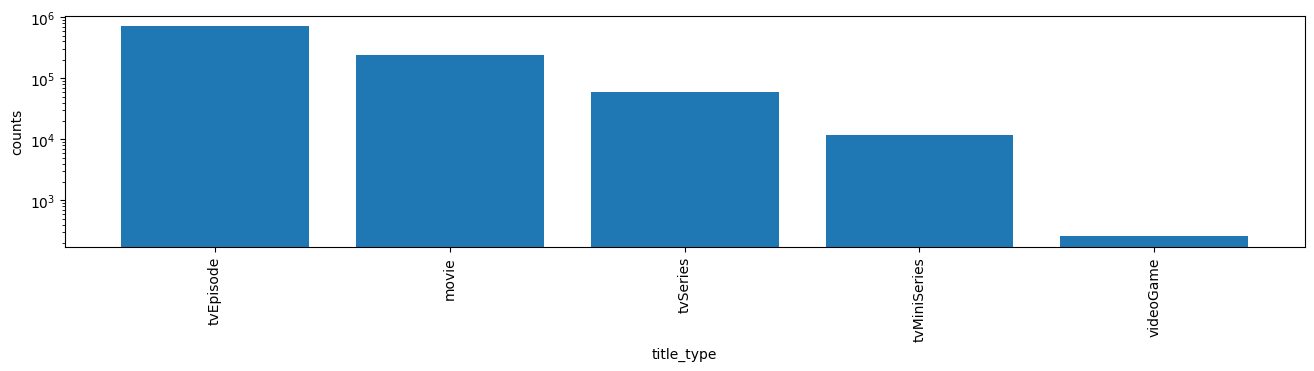

In [25]:
res_ = %sql SELECT title_type, COUNT(1) AS counts    FROM Titles    GROUP BY title_type    ORDER BY counts DESC;

plt.figure(figsize=(16,3))
res_.bar();
plt.xticks(rotation='vertical');
plt.yscale('log')

#### 3 - Find the name and rating of the oldest videogame stored in the database 

In [30]:
%%sql
SELECT T.primary_title, R.average_rating, T.start_year
FROM Titles AS T
JOIN Title_ratings AS R ON R.title_id=T.title_id
WHERE title_type='videoGame'
ORDER BY start_year
LIMIT 1;

 * mysql+mysqlconnector://root:***@db
1 rows affected.


primary_title,average_rating,start_year
Lord of the Rings,6.9,1990


### Identify interesting outliers 

#### 1 - List the names of all movies whose titles begin with "The" and have a runtime between 3 and 4 hours.

In [35]:
%%sql
SELECT primary_title, runtime_minutes#, COUNT(1) AS counts
FROM Titles
WHERE LOWER(primary_title) LIKE "the%"
 AND runtime_minutes BETWEEN 180 AND 240;

 * mysql+mysqlconnector://root:***@db
432 rows affected.


primary_title,runtime_minutes
The Great Air Race,192
The Gravy Train,205
The Cave of the Golden Rose,200
The River Kings,200
The Beautiful Troublemaker,238
The Cloning of Joanna May,180
The Gravy Train Goes East,215
The Orchid House,240
The Cave of the Golden Rose 2,180
The Life and Times of Henry Pratt,240


#### 2 - What actor had the most roles as 'Self'?

In [37]:
%%sql
SELECT N.name_, COUNT(1) AS counts
FROM Names_ AS N
JOIN Had_role AS HR ON HR.name_id=N.name_id
WHERE LOWER(HR.role_) = "self"
GROUP BY N.name_id
ORDER BY counts DESC
LIMIT 3;

 * mysql+mysqlconnector://root:***@db
3 rows affected.


name_,counts
Scott Morrison,3197
Tony Abbott,2763
Donald Trump,2210


#### 3 - Identify what TV series had more than 1,000 episodes, and identify in what year it was aired the first episode

In [48]:
%%sql

SELECT T.primary_title, T.start_year, COUNT(1) AS n_episodes
FROM Episode_belongs_to AS E
JOIN Titles AS T ON T.title_id=E.parent_tv_show_title_id
GROUP BY parent_tv_show_title_id
HAVING n_episodes>1000
ORDER BY n_episodes DESC;

 * mysql+mysqlconnector://root:***@db
308 rows affected.


primary_title,start_year,n_episodes
Charlie Rose,1991,9884
"Gute Zeiten, schlechte Zeiten",1992,7455
Judge Judy,1996,7282
Unter uns,1994,6803
Late Show with David Letterman,1993,6691
"Goede tijden, slechte tijden",1990,6550
Young Hearts,1995,6247
DAS!,1991,5433
L'invité,2000,5273
Volle Kanne,1999,5111


In [ ]:
#---> NB "HAVING"; TODO: how could be more efficient?

### It's all about the ratings 

#### 1 - Group all movies by decade and plot their overall rating distribution trend. Limit the query to the movies with at least 1000 ratings.

In [125]:
%%sql
SELECT DISTINCT T.start_year
FROM Titles AS T
WHERE T.title_type='movie'
ORDER BY T.start_year 
LIMIT 5;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


start_year
None
1990
1991
1992
1993


In [ ]:
#---> NB movie date starts from 1990!

In [123]:
%%sql
SELECT FLOOR((start_year-1900)/10) AS decade, AVG(R.average_rating) AS avg_dec_rating, STD(R.average_rating) AS std
FROM Titles AS T
JOIN Title_ratings AS R ON R.title_id=T.title_id
WHERE T.title_type='movie'
 AND R.num_votes>1000
GROUP BY decade
ORDER BY decade;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


decade,avg_dec_rating,std
None,7.599999904632568,0.0
9,6.364565547778342,1.109392147608748
10,6.246381951759197,1.155500927497725
11,6.158357727336619,1.180125053196058
12,6.268965520191386,1.2793057092674618


In [ ]:
#---> NB where to alias

In [117]:
import pandas as pd

In [ ]:
res_ = %sql SELECT FLOOR((start_year-1900)/10) AS decade, AVG(R.average_rating) AS avg_dec_rating FROM Titles AS T JOIN Title_ratings AS R ON R.title_id=T.title_id WHERE T.title_type='movie' AND R.num_votes>1000 GROUP BY decade ORDER BY decade;

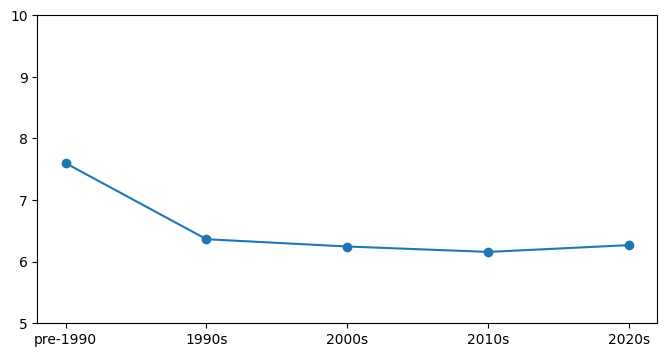

In [122]:
#print(res_)
#---> NB conversion of mysql_result type of object:
df=res_.DataFrame()
#print(df)

#--->NB this: (study?)
# Map decade to label:
label_map = {9: '1990s', 10: '2000s', 11: '2010s', 12: '2020s'}
df['label'] = df['decade'].apply(lambda x: 'pre-1990' if pd.isna(x) else label_map.get(x, str(x)))

fig,ax=plt.subplots(figsize=(8,4))
ax.plot(df['label'], df['avg_dec_rating'], 'o-')
ax.set_ylim([5,10])
plt.show()

In [ ]:
#---> TODO: prettier?

#### 2 - Plot the average rating of each episode of "Games of Thrones". Group by season and compute the average and standard deviation for each season.

In [130]:
%%sql
SELECT *
FROM Titles
WHERE primary_title="Game of Thrones"
LIMIT 3;

 * mysql+mysqlconnector://root:***@db
2 rows affected.


title_id,title_type,primary_title,start_year,runtime_minutes
tt0944947,tvSeries,Game of Thrones,2011,57
tt3109620,tvEpisode,Game of Thrones,2013,23


In [134]:
%%sql

SELECT *
FROM Episode_belongs_to AS E
JOIN Title_ratings AS R ON R.title_id=E.episode_title_id
WHERE E.parent_tv_show_title_id='tt0944947'
ORDER BY E.season_number, E.episode_number
LIMIT 20;

 * mysql+mysqlconnector://root:***@db
20 rows affected.


episode_title_id,parent_tv_show_title_id,season_number,episode_number,title_id,average_rating,num_votes
tt1480055,tt0944947,1,1,tt1480055,9.1,45688
tt1668746,tt0944947,1,2,tt1668746,8.8,34688
tt1829962,tt0944947,1,3,tt1829962,8.7,32849
tt1829963,tt0944947,1,4,tt1829963,8.8,31231
tt1829964,tt0944947,1,5,tt1829964,9.1,32486
tt1837862,tt0944947,1,6,tt1837862,9.2,32131
tt1837863,tt0944947,1,7,tt1837863,9.2,32645
tt1837864,tt0944947,1,8,tt1837864,9.0,30542
tt1851398,tt0944947,1,9,tt1851398,9.6,42665
tt1851397,tt0944947,1,10,tt1851397,9.5,37555


In [135]:
res_= %sql SELECT * FROM Episode_belongs_to AS E JOIN Title_ratings AS R ON R.title_id=E.episode_title_id WHERE E.parent_tv_show_title_id='tt0944947' ORDER BY E.season_number, E.episode_number;

 * mysql+mysqlconnector://root:***@db
73 rows affected.


In [138]:
import numpy as np

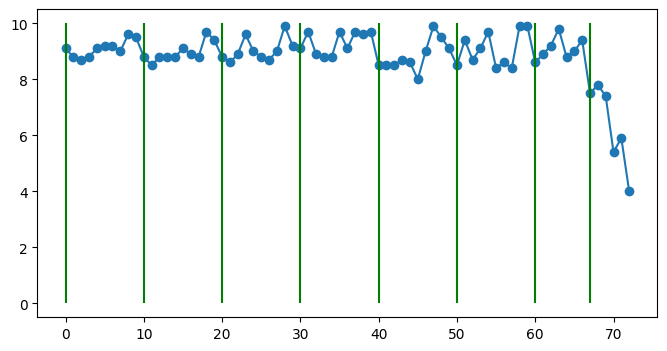

In [147]:
df=res_.DataFrame()
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(range(len(df)), df['average_rating'], 'o-')
#ax.set_ylim([5,10])
#diff_array=np.asarray(df['season_number'])-np.concatenate(np.zeros(1), np.asarray(df['season_number']))
ax.vlines(np.where(df['episode_number']==1),0,10, color='green')
plt.show()

In [ ]:
#---> prettier?

In [155]:
%%sql

SELECT E.season_number, ROUND(AVG(R.average_rating),2) AS "Average season rating", ROUND(STD(R.average_rating),2) AS "Standard deviation over episodes"
FROM Episode_belongs_to AS E
JOIN Title_ratings AS R ON R.title_id=E.episode_title_id
WHERE E.parent_tv_show_title_id='tt0944947'
GROUP BY E.season_number
ORDER BY E.season_number
LIMIT 20;

 * mysql+mysqlconnector://root:***@db
8 rows affected.


season_number,Average season rating,Standard deviation over episodes
1,9.1,0.28
2,8.96,0.33
3,9.05,0.39
4,9.31,0.38
5,8.83,0.53
6,9.06,0.59
7,9.1,0.37
8,6.33,1.36


In [ ]:
#---> NB "ROUND()"

#### 3 - Plot the total number of movies produced per year, divided by genre (Action, Comedy, Drama, Thriller, Fantasy), and the yearly rating average per genre

In [160]:
%%sql
SELECT DISTINCT G.genre
FROM Titles AS T
JOIN Title_genres AS G ON G.title_id=T.title_id
WHERE T.title_type='movie';

 * mysql+mysqlconnector://root:***@db
25 rows affected.


genre
Drama
Mystery
Romance
Comedy
Fantasy
Documentary
Sport
Action
War
Crime


In [171]:
%%sql
SELECT T.start_year, G.genre AS genre, COUNT(1) AS counts, AVG(R.average_rating) AS "average rating"
FROM Titles AS T
JOIN Title_genres AS G ON G.title_id=T.title_id
JOIN Title_ratings AS R ON R.title_id=T.title_id
WHERE T.title_type='movie'
 AND genre IN ('Action','Comedy', 'Drama', 'Thriller', 'Fantasy')
GROUP BY T.start_year, G.genre
ORDER BY T.start_year;

 * mysql+mysqlconnector://root:***@db
168 rows affected.


start_year,genre,counts,average rating
None,Action,2,6.599999904632568
None,Comedy,10,5.079999947547913
None,Drama,6,7.100000063578288
1990,Action,385,5.513246741232934
1990,Comedy,550,5.837272716435519
1990,Drama,975,6.179179479770172
1990,Fantasy,96,5.828124990065892
1990,Thriller,189,5.478306881334416
1991,Action,348,5.474999997122534
1991,Comedy,563,5.90976910142238


In [ ]:
#---> NB this: (review details?)

In [ ]:
res_ = %sql SELECT T.start_year, G.genre AS genre, COUNT(1) AS counts, AVG(R.average_rating) AS "average rating" FROM Titles AS T JOIN Title_genres AS G ON G.title_id=T.title_id JOIN Title_ratings AS R ON R.title_id=T.title_id WHERE T.title_type='movie' AND genre IN ('Action','Comedy', 'Drama', 'Thriller', 'Fantasy') GROUP BY T.start_year, G.genre ORDER BY T.start_year;

 * mysql+mysqlconnector://root:***@db
168 rows affected.


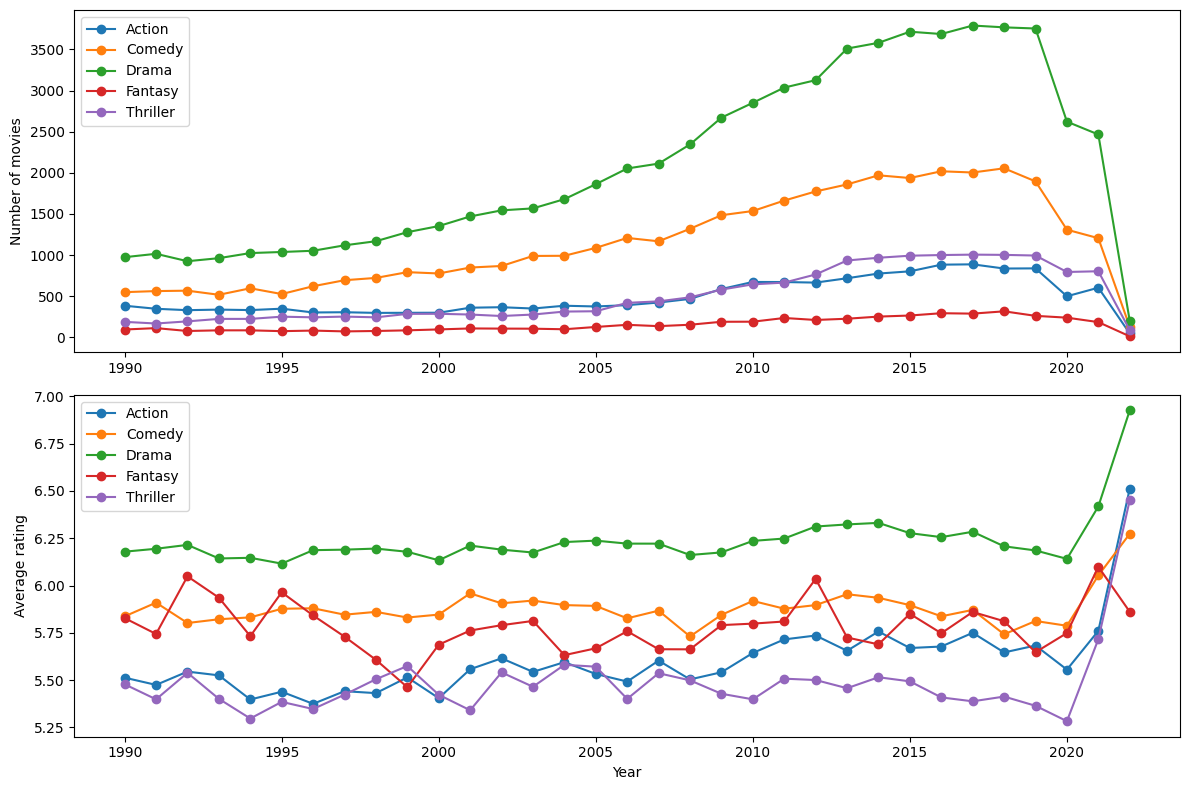

In [172]:
df = res_.DataFrame()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
for genre in df['genre'].unique():
    subset = df[df['genre'] == genre] #---> NB this
    ax1.plot(subset['start_year'], subset['counts'], 'o-', label=genre)
    ax2.plot(subset['start_year'], subset['average rating'], 'o-', label=genre)
ax1.set_ylabel('Number of movies')
ax2.set_ylabel('Average rating')
ax2.set_xlabel('Year')
ax1.legend(), ax2.legend()
plt.tight_layout()